EDA (Eksplorasi Data)

--- 5 Baris Pertama ---
   customer_id  gender   age  country     city          signup_date  \
0        10001    Male  52.0    India   Berlin  2022-05-10 00:00:00   
1        10002     NaN  35.0  Germany   Mumbai  2024-06-16 00:00:00   
2        10003  Female  27.0  Germany   London  2023-08-23 00:00:00   
3        10004  Female  36.0    India   Mumbai  2024-01-28 00:00:00   
4        10005    Male  29.0      USA  Hamburg  2023-07-21 00:00:00   

    last_purchase_date acquisition_channel device_type subscription_type  ...  \
0  2024-12-31 00:00:00               Email      Tablet            Annual  ...   
1  2024-05-07 00:00:00             Organic     Desktop           Monthly  ...   
2  2024-04-28 00:00:00               Email      Mobile            Annual  ...   
3  2023-05-20 00:00:00        Facebook Ads      Tablet            Annual  ...   
4  2024-04-07 00:00:00            Referral      Mobile           Monthly  ...   

   support_tickets  refund_requested  delivery_delay_days  pay

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15740\2237579142.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_val.values, y=missing_val.index, palette='viridis')


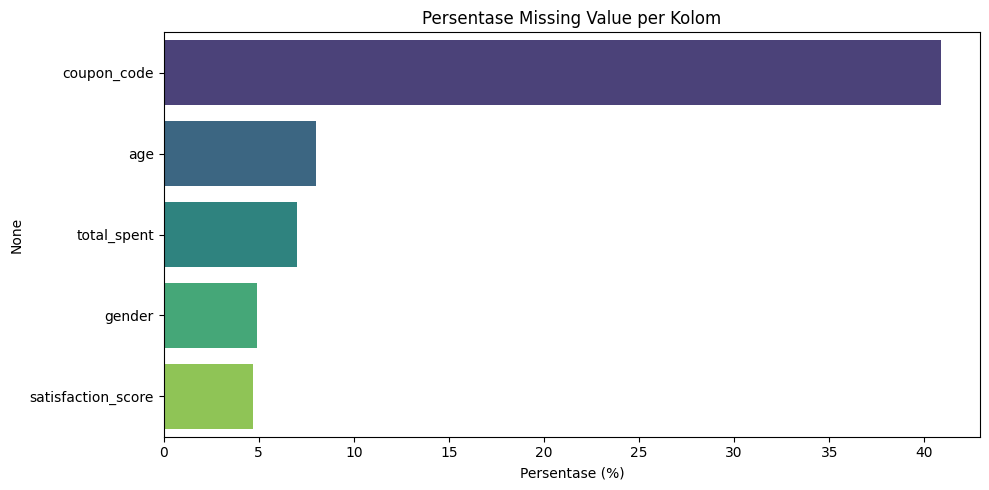

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15740\2237579142.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='churn', palette='Set2')


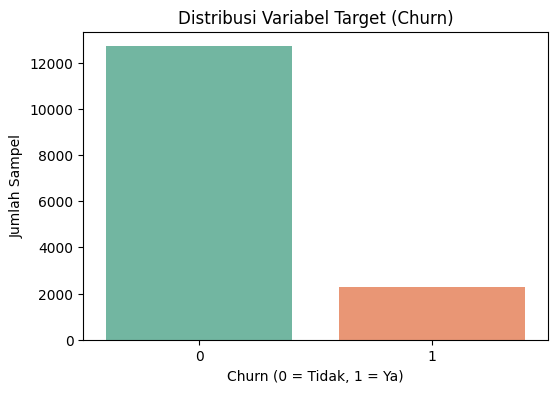

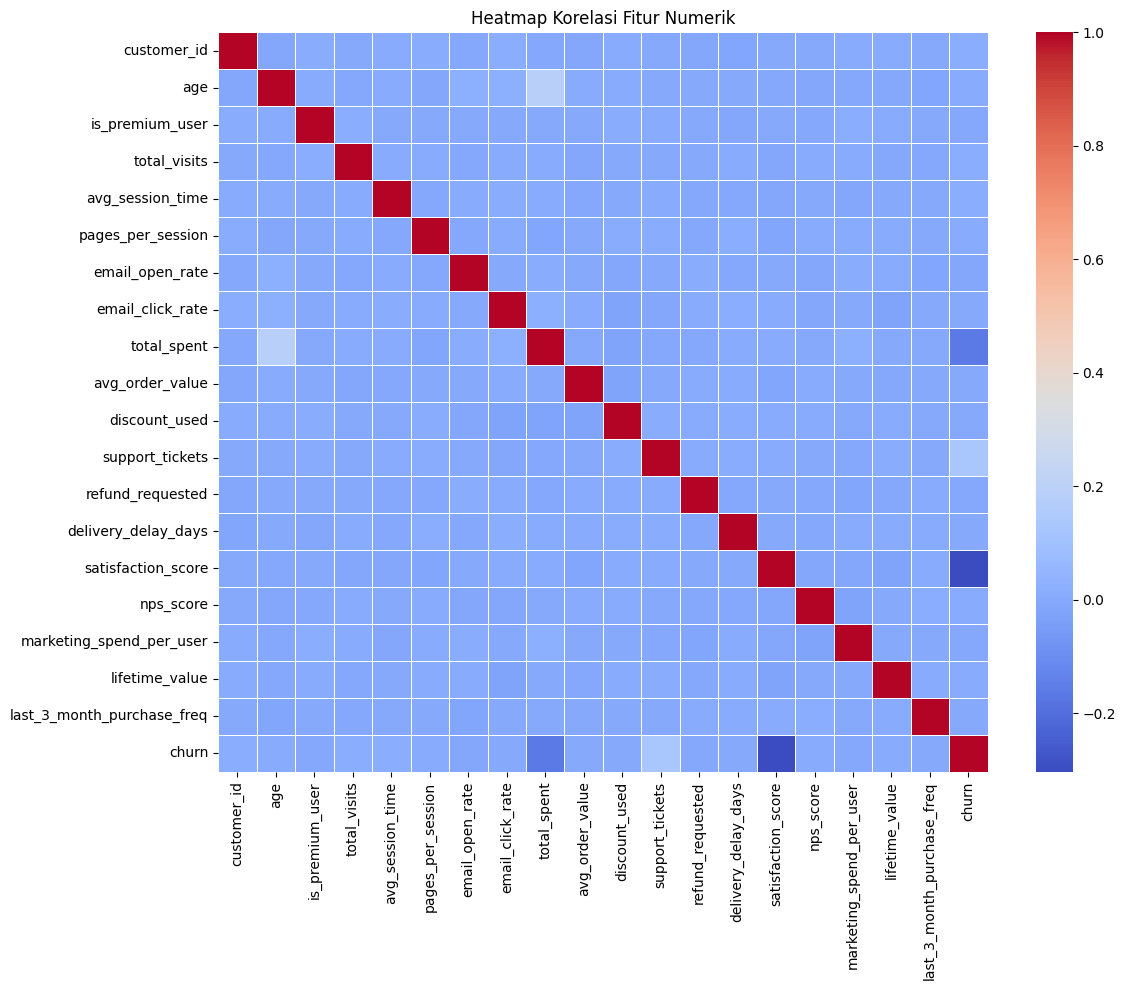

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Memuat dataset (sesuaikan nama file dengan yang Anda download)
df = pd.read_csv('Sales - Marketing customer dataset.csv')

# Tugas 1: Menampilkan 5 baris pertama, info dataset, dan statistik deskriptif
print("--- 5 Baris Pertama ---")
print(df.head())

print("\n--- Informasi Dataset ---")
print(df.info())

print("\n--- Statistik Deskriptif ---")
print(df.describe(include='all'))

# Tugas 2: Menghitung persentase missing value dan visualisasi
missing_val = df.isnull().sum() / len(df) * 100
missing_val = missing_val[missing_val > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
if not missing_val.empty:
    sns.barplot(x=missing_val.values, y=missing_val.index, palette='viridis')
    plt.title('Persentase Missing Value per Kolom')
    plt.xlabel('Persentase (%)')
else:
    plt.text(0.5, 0.5, 'Tidak ada missing value', ha='center', va='center')
    plt.title('Pengecekan Missing Value')
plt.tight_layout()
plt.show()

# Tugas 3: Visualisasi distribusi variabel target (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Distribusi Variabel Target (Churn)')
plt.xlabel('Churn (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Sampel')
plt.show()

# Tugas 4: Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

Direct Modeling (Tanpa Preprocessing)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Kolom non-numerik dan ID yang harus diabaikan di awal agar model tidak error
drop_cols_direct = ['customer id', 'gender', 'country', 'city', 'signup_date', 
                     'last_purchase_date', 'acquisition_channel', 'device_type', 
                     'subscription_type', 'coupon_code', 'payment_method']

# Memisahkan data numerik saja yang tersedia langsung
# Tambahkan errors='ignore' di dalam fungsi drop
df_direct = df.drop(columns=drop_cols_direct, errors='ignore').dropna()

# Tugas 1: Menetapkan X dan y
X_direct = df_direct.drop(columns=['churn'])
y_direct = df_direct['churn']

# Tugas 2: Train-test split (Proporsi 80:20)
X_train_dir, X_test_dir, y_train_dir, y_test_dir = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

# Tugas 3 & 4: Inisialisasi dan Pelatihan 3 Kategori Model
clf1 = LogisticRegression(max_iter=1000, random_state=42)
clf2 = RandomForestClassifier(random_state=42)
clf3 = VotingClassifier(estimators=[('lr', clf1), ('rf', clf2)], voting='soft')

models_direct = {
    'Logistic Regression (Konvensional)': clf1,
    'Random Forest (Bagging)': clf2,
    'Voting Classifier (Ensemble)': clf3
}

print("\n=== HASIL DIRECT MODELING ===")
for name, model in models_direct.items():
    model.fit(X_train_dir, y_train_dir)
    y_pred = model.predict(X_test_dir)
    
    # Tugas 5: Evaluasi Performa
    print(f"\nModel: {name}")
    print(f"Accuracy : {accuracy_score(y_test_dir, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_dir, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test_dir, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test_dir, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_dir, y_pred))


=== HASIL DIRECT MODELING ===


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression (Konvensional)
Accuracy : 0.8412
Precision: 0.5000
Recall   : 0.1414
F1-Score : 0.2204
Confusion Matrix:
[[2006   55]
 [ 334   55]]

Model: Random Forest (Bagging)
Accuracy : 0.8420
Precision: 0.5034
Recall   : 0.3753
F1-Score : 0.4300
Confusion Matrix:
[[1917  144]
 [ 243  146]]


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Voting Classifier (Ensemble)
Accuracy : 0.8412
Precision: 0.5000
Recall   : 0.1620
F1-Score : 0.2447
Confusion Matrix:
[[1998   63]
 [ 326   63]]


Modeling Dengan Preprocessing

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Salin dataset awal
df_prep = df.copy()

# 1. Menghapus fitur yang tidak relevan (seperti ID atau Tanggal yang terlalu spesifik)
df_prep = df_prep.drop(columns=['customer id', 'signup_date', 'last_purchase_date', 'coupon_code'], errors='ignore')

# Menghapus duplikasi jika ada
df_prep = df_prep.drop_duplicates()

# Menentukan X dan y kembali
X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

# 2. Train-test split sebelum preprocessing (menghindari data leakage)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep, test_size=0.2, random_state=42, stratify=y_prep
)

# Identifikasi jenis kolom
cat_cols = X_train_p.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train_p.select_dtypes(include=[np.number]).columns.tolist()

# Imputasi (Penanganan Missing Value)
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_p[num_cols] = num_imputer.fit_transform(X_train_p[num_cols])
X_test_p[num_cols] = num_imputer.transform(X_test_p[num_cols])

X_train_p[cat_cols] = cat_imputer.fit_transform(X_train_p[cat_cols])
X_test_p[cat_cols] = cat_imputer.transform(X_test_p[cat_cols])

# Encoding untuk fitur kategorikal
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat_encoded = encoder.fit_transform(X_train_p[cat_cols])
X_test_cat_encoded = encoder.transform(X_test_p[cat_cols])

encoded_cat_cols = encoder.get_feature_names_out(cat_cols)

# Scaling untuk fitur numerik
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_p[num_cols])
X_test_num_scaled = scaler.transform(X_test_p[num_cols])

# Gabungkan kembali kolom numerik dan kategorikal hasil transformasi
X_train_final = np.hstack((X_train_num_scaled, X_train_cat_encoded))
X_test_final = np.hstack((X_test_num_scaled, X_test_cat_encoded))

all_features = num_cols + list(encoded_cat_cols)

# Latih ulang 3 model menggunakan data hasil preprocessing
clf1_p = LogisticRegression(max_iter=1000, random_state=42)
clf2_p = RandomForestClassifier(random_state=42)
clf3_p = VotingClassifier(estimators=[('lr', clf1_p), ('rf', clf2_p)], voting='soft')

models_prep = {
    'Logistic Regression (Dengan Preprocessing)': clf1_p,
    'Random Forest (Dengan Preprocessing)': clf2_p,
    'Voting Classifier (Dengan Preprocessing)': clf3_p
}

print("\n=== HASIL MODELING DENGAN PREPROCESSING ===")
for name, model in models_prep.items():
    model.fit(X_train_final, y_train_p)
    y_pred = model.predict(X_test_final)
    
    print(f"\nModel: {name}")
    print(f"Accuracy : {accuracy_score(y_test_p, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_p, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test_p, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test_p, y_pred):.4f}")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15740\250669882.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_p.select_dtypes(include=['object']).columns.tolist()



=== HASIL MODELING DENGAN PREPROCESSING ===

Model: Logistic Regression (Dengan Preprocessing)
Accuracy : 0.8463
Precision: 0.4966
Recall   : 0.1565
F1-Score : 0.2380

Model: Random Forest (Dengan Preprocessing)
Accuracy : 0.8507
Precision: 0.5288
Recall   : 0.2391
F1-Score : 0.3293

Model: Voting Classifier (Dengan Preprocessing)
Accuracy : 0.8473
Precision: 0.5075
Recall   : 0.1478
F1-Score : 0.2290


Hyperparameter Tuning & Feature Selection

In [12]:
from sklearn.model_selection import GridSearchCV

# Tugas 1: Analisis Feature Importance (menggunakan Random Forest yang sudah dilatih)
importances = clf2_p.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- Top 5 Fitur Paling Berpengaruh (Feature Importance) ---")
for f in range(5):
    print(f"{f + 1}. {all_features[indices[f]]} ({importances[indices[f]]*100:.2f}%)")

# Tugas 2 & 3: Menyusun Parameter Grid & Tuning menggunakan GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

print("\nMelakukan Hyperparameter Tuning pada Random Forest... (Mohon tunggu)")
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_final, y_train_p)

# Tugas 4 & 5: Memperoleh best estimator
best_rf_model = grid_search.best_estimator_
print(f"Parameter Terbaik: {grid_search.best_params_}")

# Tugas 6: Evaluasi Model Optimal
y_pred_opt = best_rf_model.predict(X_test_final)
print("\n=== HASIL OPTIMAL MODEL (HYPERPARAMETER TUNING) ===")
print(f"Accuracy : {accuracy_score(y_test_p, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test_p, y_pred_opt):.4f}")
print(f"Recall   : {recall_score(y_test_p, y_pred_opt):.4f}")
print(f"F1-Score : {f1_score(y_test_p, y_pred_opt):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test_p, y_pred_opt))

# MENYIMPAN MODEL TERBAIK DAN OBJECT PREPROCESSING UNTUK DEPLOYMENT
import joblib
joblib.dump(best_rf_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(num_imputer, 'num_imputer.pkl')
joblib.dump(cat_imputer, 'cat_imputer.pkl')
joblib.dump(num_cols, 'num_cols.pkl')
joblib.dump(cat_cols, 'cat_cols.pkl')
print("\nModel dan komponen preprocessing berhasil disimpan!")


--- Top 5 Fitur Paling Berpengaruh (Feature Importance) ---
1. total_spent (18.81%)
2. satisfaction_score (16.57%)
3. support_tickets (6.74%)
4. pages_per_session (4.02%)
5. customer_id (3.93%)

Melakukan Hyperparameter Tuning pada Random Forest... (Mohon tunggu)
Parameter Terbaik: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}

=== HASIL OPTIMAL MODEL (HYPERPARAMETER TUNING) ===
Accuracy : 0.8453
Precision: 0.4912
Recall   : 0.2413
F1-Score : 0.3236
Confusion Matrix:
[[2425  115]
 [ 349  111]]

Model dan komponen preprocessing berhasil disimpan!
